# Supplementary Figure S8 — structural breadth in reduced and complete ensembles

This analysis evaluates WT structural breadth and trajectory retention in Kv2.1, NaV1.5, and CaV1.2. The First100 cohort contains 100 nominal model–seed trajectories formed from the first 20 input seeds and five model parameterizations per seed. It is compared with the complete final-QC ensemble. Structural breadth is quantified from chain-safe distance IQRs and summarized across seeds and structural regions.

In [1]:
from pathlib import Path
import sys, copy, importlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from IPython.display import display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'shared').is_dir())
sys.path.insert(0, str(repo_root))
import shared.cross_channel_distance_figure as figure2
importlib.reload(figure2)
from shared.sampling_depth_analysis import first_nominal_trajectory_cohort, latest_qc_trajectory_representatives, _kv21_ranked_ring_columns
from shared.plotting import add_s6_cross_pore_columns, KV21_PALETTE, NAV15_PALETTE, CAV12_PALETTE
from shared.distribution_statistics import exact_common_distance_columns

OUT = repo_root / 'docs' / 'figures' / 'supplementary_figure_s8'
TAB = repo_root / 'docs' / 'tables' / 'supplementary_figure_s8'
OUT.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
CHANNELS = ['Kv2.1', 'Nav1.5', 'Cav1.2']
DISPLAY = {'Kv2.1': 'Kv2.1', 'Nav1.5': 'NaV1.5', 'Cav1.2': 'CaV1.2'}
COLORS = {
    'Kv2.1': {'Vanilla': KV21_PALETTE['WT_VAN'], 'Masked': KV21_PALETTE['WT_HM']},
    'Nav1.5': {'Vanilla': NAV15_PALETTE['WT_VAN'], 'Masked': NAV15_PALETTE['WT_HM']},
    'Cav1.2': {'Vanilla': CAV12_PALETTE['WT_VAN'], 'Masked': CAV12_PALETTE['WT_HM']},
}
sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({'font.family': 'Arial', 'axes.edgecolor': '#333333', 'axes.titleweight': 'semibold',
                     'grid.color': '#E5E8E5', 'grid.linewidth': .55, 'pdf.fonttype': 42})

## WT First100 and complete-QC ensembles

In [2]:
configs = figure2.paper_configs(repo_root)
first100 = {}; full = {}
for channel in CHANNELS:
    first100[channel] = {}; full[channel] = {}
    for protocol in ('vanilla', 'masked'):
        raw = pd.read_csv(configs[channel][protocol], low_memory=False)
        full[channel][protocol] = latest_qc_trajectory_representatives(raw).copy()
        early = first_nominal_trajectory_cohort(raw, number_seeds=20)
        first100[channel][protocol] = latest_qc_trajectory_representatives(early).copy()

aliases = copy.deepcopy(figure2.ALIASES)
for protocol in ('vanilla', 'masked'):
    frame, sf_aliases = _kv21_ranked_ring_columns(first100['Kv2.1'][protocol])
    frame, gate_aliases = add_s6_cross_pore_columns(frame)
    first100['Kv2.1'][protocol] = frame
    full_frame, _ = _kv21_ranked_ring_columns(full['Kv2.1'][protocol])
    full_frame, _ = add_s6_cross_pore_columns(full_frame)
    full['Kv2.1'][protocol] = full_frame
aliases['Kv2.1']['selectivity_filter'] = sf_aliases
aliases['Kv2.1']['intracellular_gate'] = {f'{k} cross-pore': v for k, v in gate_aliases.items()}

REGIONS = [('intracellular_gate', 'Intracellular gate'),
           ('selectivity_filter', 'Selectivity filter'),
           ('vsds', 'Voltage-sensor domain')]
representatives = {(channel, region): list(aliases[channel][region].items())[:2]
                   for channel in CHANNELS for region, _ in REGIONS}
display(pd.DataFrame([{'channel': DISPLAY[c], 'region': title, 'coordinate': alias}
                      for c in CHANNELS for r, title in REGIONS for alias, _ in representatives[c, r]]))

breadth_rows = []
for channel in CHANNELS:
    for region, region_title in REGIONS:
        for alias, column in representatives[channel, region]:
            for cohort, frames in [('First100', first100), ('Full QC', full)]:
                viqr = pd.to_numeric(frames[channel]['vanilla'][column], errors='coerce').dropna().quantile(.75) - pd.to_numeric(frames[channel]['vanilla'][column], errors='coerce').dropna().quantile(.25)
                miqr = pd.to_numeric(frames[channel]['masked'][column], errors='coerce').dropna().quantile(.75) - pd.to_numeric(frames[channel]['masked'][column], errors='coerce').dropna().quantile(.25)
                pooled_values = pd.concat([pd.to_numeric(frames[channel]['vanilla'][column], errors='coerce'),
                                           pd.to_numeric(frames[channel]['masked'][column], errors='coerce')]).dropna()
                pooled_iqr = pooled_values.quantile(.75) - pooled_values.quantile(.25)
                breadth_rows.append({'channel': channel, 'region': region_title, 'coordinate': alias,
                                     'cohort': cohort, 'vanilla_IQR': viqr, 'masked_IQR': miqr,
                                     'pooled_IQR': pooled_iqr,
                                     'vanilla_normalized_IQR': viqr / pooled_iqr if pooled_iqr > 0 else np.nan,
                                     'masked_normalized_IQR': miqr / pooled_iqr if pooled_iqr > 0 else np.nan,
                                     'IQR_ratio': miqr / viqr if viqr > 0 else np.nan})
breadth = pd.DataFrame(breadth_rows)
breadth.to_csv(TAB / 'wt_selected_coordinate_breadth.csv', index=False)

# Region assignment uses all predefined Figure-2 landmark distances. Other is
# the remainder of the exact shared eligible distance panel. Raw Kv2.1
# interchain columns are excluded because homotetramer chain labels can permute.
def kv_chain_safe(column):
    if not column.startswith(('CA_', 'shortest_')):
        return False
    match = re.match(r'^CA_CA_([A-Za-z0-9])_.*?-([A-Za-z0-9])_', column)
    if match: return match.group(1) == match.group(2)
    match = re.match(r'^shortest_[A-Z]{3}\d+([A-Za-z0-9])-[A-Z]{3}\d+([A-Za-z0-9])$', column)
    return bool(match and match.group(1) == match.group(2))

region_columns = {}; eligible_columns = {}
for channel in CHANNELS:
    defined = {title: [column for _, column in aliases[channel][region].items()
                       if column in full[channel]['vanilla'] and column in full[channel]['masked']]
               for region, title in REGIONS}
    shared = exact_common_distance_columns(full[channel]['vanilla'], full[channel]['masked'])
    if channel == 'Kv2.1':
        shared = [column for column in shared if kv_chain_safe(column)]
    assigned = set(sum(defined.values(), []))
    defined['Other'] = [column for column in shared if column not in assigned]
    region_columns[channel] = defined
    eligible_columns[channel] = list(dict.fromkeys(sum(defined.values(), [])))

seed_breadth_rows = []; regional_breadth_rows = []
for channel in CHANNELS:
    columns = eligible_columns[channel]
    pooled = pd.concat([full[channel]['vanilla'][columns], full[channel]['masked'][columns]], ignore_index=True)
    scale = (pooled.apply(pd.to_numeric, errors='coerce').quantile(.75)
             - pooled.apply(pd.to_numeric, errors='coerce').quantile(.25)).replace(0, np.nan)
    for cohort, frames in [('First100', first100), ('All', full)]:
        for protocol in ('vanilla', 'masked'):
            frame = frames[channel][protocol].copy()
            frame['seed'] = pd.to_numeric(frame.pdb_file.astype(str).str.extract(r'_seed_(\d+)', expand=False),
                                          errors='coerce')
            numeric = frame[columns].apply(pd.to_numeric, errors='coerce')
            numeric['seed'] = frame['seed']
            within_seed = numeric.groupby('seed')[columns].quantile(.75) - numeric.groupby('seed')[columns].quantile(.25)
            values = within_seed.div(scale, axis=1).median(axis=1, skipna=True)
            seed_breadth_rows.extend({'channel': channel, 'cohort': cohort, 'protocol': protocol,
                                      'seed': int(seed), 'normalized_seed_breadth': value}
                                     for seed, value in values.dropna().items())
            for region_name, region_cols in region_columns[channel].items():
                region_values = within_seed[region_cols].div(scale[region_cols], axis=1).median(axis=1, skipna=True)
                regional_breadth_rows.extend({'channel': channel, 'cohort': cohort, 'protocol': protocol,
                                               'region': region_name, 'seed': int(seed),
                                               'normalized_seed_breadth': value}
                                              for seed, value in region_values.dropna().items())
seed_breadth = pd.DataFrame(seed_breadth_rows)
regional_breadth = pd.DataFrame(regional_breadth_rows)
seed_breadth.to_csv(TAB / 'wt_global_seed_breadth.csv', index=False)
regional_breadth.to_csv(TAB / 'wt_regional_seed_breadth.csv', index=False)
display(pd.DataFrame([{'channel': c, 'region': r, 'distances': len(cols)}
                      for c in CHANNELS for r, cols in region_columns[c].items()]))
display(breadth); display(seed_breadth); display(regional_breadth)

,channel,region,coordinate
0,Kv2.1,Intracellular gate,V398 cross-pore
1,Kv2.1,Intracellular gate,I401 cross-pore
2,Kv2.1,Selectivity filter,G375 ring rank 1
3,Kv2.1,Selectivity filter,G375 ring rank 2
4,Kv2.1,Voltage-sensor domain,F236–R308 A
5,Kv2.1,Voltage-sensor domain,F236–R308 B
6,NaV1.5,Intracellular gate,M415–A742
7,NaV1.5,Intracellular gate,M415–I1154
8,NaV1.5,Selectivity filter,D373–E704
9,NaV1.5,Selectivity filter,D373–K1103


,channel,region,distances
0,Kv2.1,Intracellular gate,6
1,Kv2.1,Selectivity filter,6
2,Kv2.1,Voltage-sensor domain,4
3,Kv2.1,Other,542
4,Nav1.5,Intracellular gate,6
5,Nav1.5,Selectivity filter,6
6,Nav1.5,Voltage-sensor domain,7
7,Nav1.5,Other,995
8,Cav1.2,Intracellular gate,6
9,Cav1.2,Selectivity filter,6


,channel,region,coordinate,cohort,vanilla_IQR,masked_IQR,pooled_IQR,vanilla_normalized_IQR,masked_normalized_IQR,IQR_ratio
0,Kv2.1,Intracellular gate,V398 cross-pore,First100,0.2900,0.3975,0.3700,0.783784,1.074324,1.370690
1,Kv2.1,Intracellular gate,V398 cross-pore,Full QC,0.2900,0.3900,0.3500,0.828571,1.114286,1.344828
2,Kv2.1,Intracellular gate,I401 cross-pore,First100,0.1600,1.9300,0.3400,0.470588,5.676471,12.062500
3,Kv2.1,Intracellular gate,I401 cross-pore,Full QC,0.1500,0.9750,0.3000,0.500000,3.250000,6.500000
4,Kv2.1,Selectivity filter,G375 ring rank 1,First100,1.6000,1.0050,1.3800,1.159420,0.728261,0.628125
5,Kv2.1,Selectivity filter,G375 ring rank 1,Full QC,1.5800,0.9750,1.4875,1.062185,0.655462,0.617089
6,Kv2.1,Selectivity filter,G375 ring rank 2,First100,1.6200,1.0075,1.2800,1.265625,0.787109,0.621914
7,Kv2.1,Selectivity filter,G375 ring rank 2,Full QC,1.5950,0.9500,1.4200,1.123239,0.669014,0.595611
8,Kv2.1,Voltage-sensor domain,F236–R308 A,First100,0.1700,0.2850,0.2300,0.739130,1.239130,1.676471
9,Kv2.1,Voltage-sensor domain,F236–R308 A,Full QC,0.1600,0.2800,0.2100,0.761905,1.333333,1.750000


,channel,cohort,protocol,seed,normalized_seed_breadth
0,Kv2.1,First100,vanilla,48,0.585784
1,Kv2.1,First100,vanilla,49,0.524128
2,Kv2.1,First100,vanilla,50,0.548438
3,Kv2.1,First100,vanilla,51,0.589572
4,Kv2.1,First100,vanilla,52,0.500000
...,...,...,...,...,...
715,Cav1.2,All,masked,186,0.533333
716,Cav1.2,All,masked,187,0.575347
717,Cav1.2,All,masked,188,0.571429
718,Cav1.2,All,masked,189,0.525892


,channel,cohort,protocol,region,seed,normalized_seed_breadth
0,Kv2.1,First100,vanilla,Intracellular gate,48,0.619183
1,Kv2.1,First100,vanilla,Intracellular gate,49,0.410437
2,Kv2.1,First100,vanilla,Intracellular gate,50,0.454792
3,Kv2.1,First100,vanilla,Intracellular gate,51,0.635659
4,Kv2.1,First100,vanilla,Intracellular gate,52,0.488246
...,...,...,...,...,...,...
2875,Cav1.2,All,masked,Other,186,0.531129
2876,Cav1.2,All,masked,Other,187,0.582483
2877,Cav1.2,All,masked,Other,188,0.574765
2878,Cav1.2,All,masked,Other,189,0.525446


## Trajectory retention across recycles

In [3]:
seed_re = re.compile(r'_seed_(\d+)', re.I)
model_re = re.compile(r'_model_(\d+)', re.I)
recycle_re = re.compile(r'\.r(\d+)\.pdb$', re.I)
rows = []
for channel in CHANNELS:
    for protocol in ('vanilla', 'masked'):
        raw = pd.read_csv(configs[channel][protocol], usecols=['pdb_file'])
        names = raw.pdb_file.astype(str)
        parsed = pd.DataFrame({
            'seed': pd.to_numeric(names.str.extract(seed_re, expand=False), errors='coerce'),
            'model': pd.to_numeric(names.str.extract(model_re, expand=False), errors='coerce'),
            'recycle': pd.to_numeric(names.str.extract(recycle_re, expand=False), errors='coerce'),
        }).dropna().astype(int)
        first_seeds = sorted(parsed.seed.unique())[:20]
        for cohort, cohort_data, nominal in [
            ('First100', parsed[parsed.seed.isin(first_seeds)], 100),
            ('All', parsed, 500),
        ]:
            for recycle in range(1, 11):
                retained = cohort_data.loc[cohort_data.recycle == recycle, ['seed', 'model']].drop_duplicates().shape[0]
                rows.append({'channel': channel, 'cohort': cohort, 'protocol': protocol,
                             'recycle': recycle, 'nominal': nominal, 'retained': retained,
                             'retained_fraction': retained / nominal})
retention = pd.DataFrame(rows)
retention.to_csv(TAB / 'wt_retention_by_recycle.csv', index=False)
display(retention)

,channel,cohort,protocol,recycle,nominal,retained,retained_fraction
0,Kv2.1,First100,vanilla,1,100,41,0.41
1,Kv2.1,First100,vanilla,2,100,92,0.92
2,Kv2.1,First100,vanilla,3,100,95,0.95
3,Kv2.1,First100,vanilla,4,100,95,0.95
4,Kv2.1,First100,vanilla,5,100,97,0.97
...,...,...,...,...,...,...,...
115,Cav1.2,All,masked,6,500,500,1.00
116,Cav1.2,All,masked,7,500,500,1.00
117,Cav1.2,All,masked,8,500,500,1.00
118,Cav1.2,All,masked,9,500,500,1.00


## Figure assembly

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


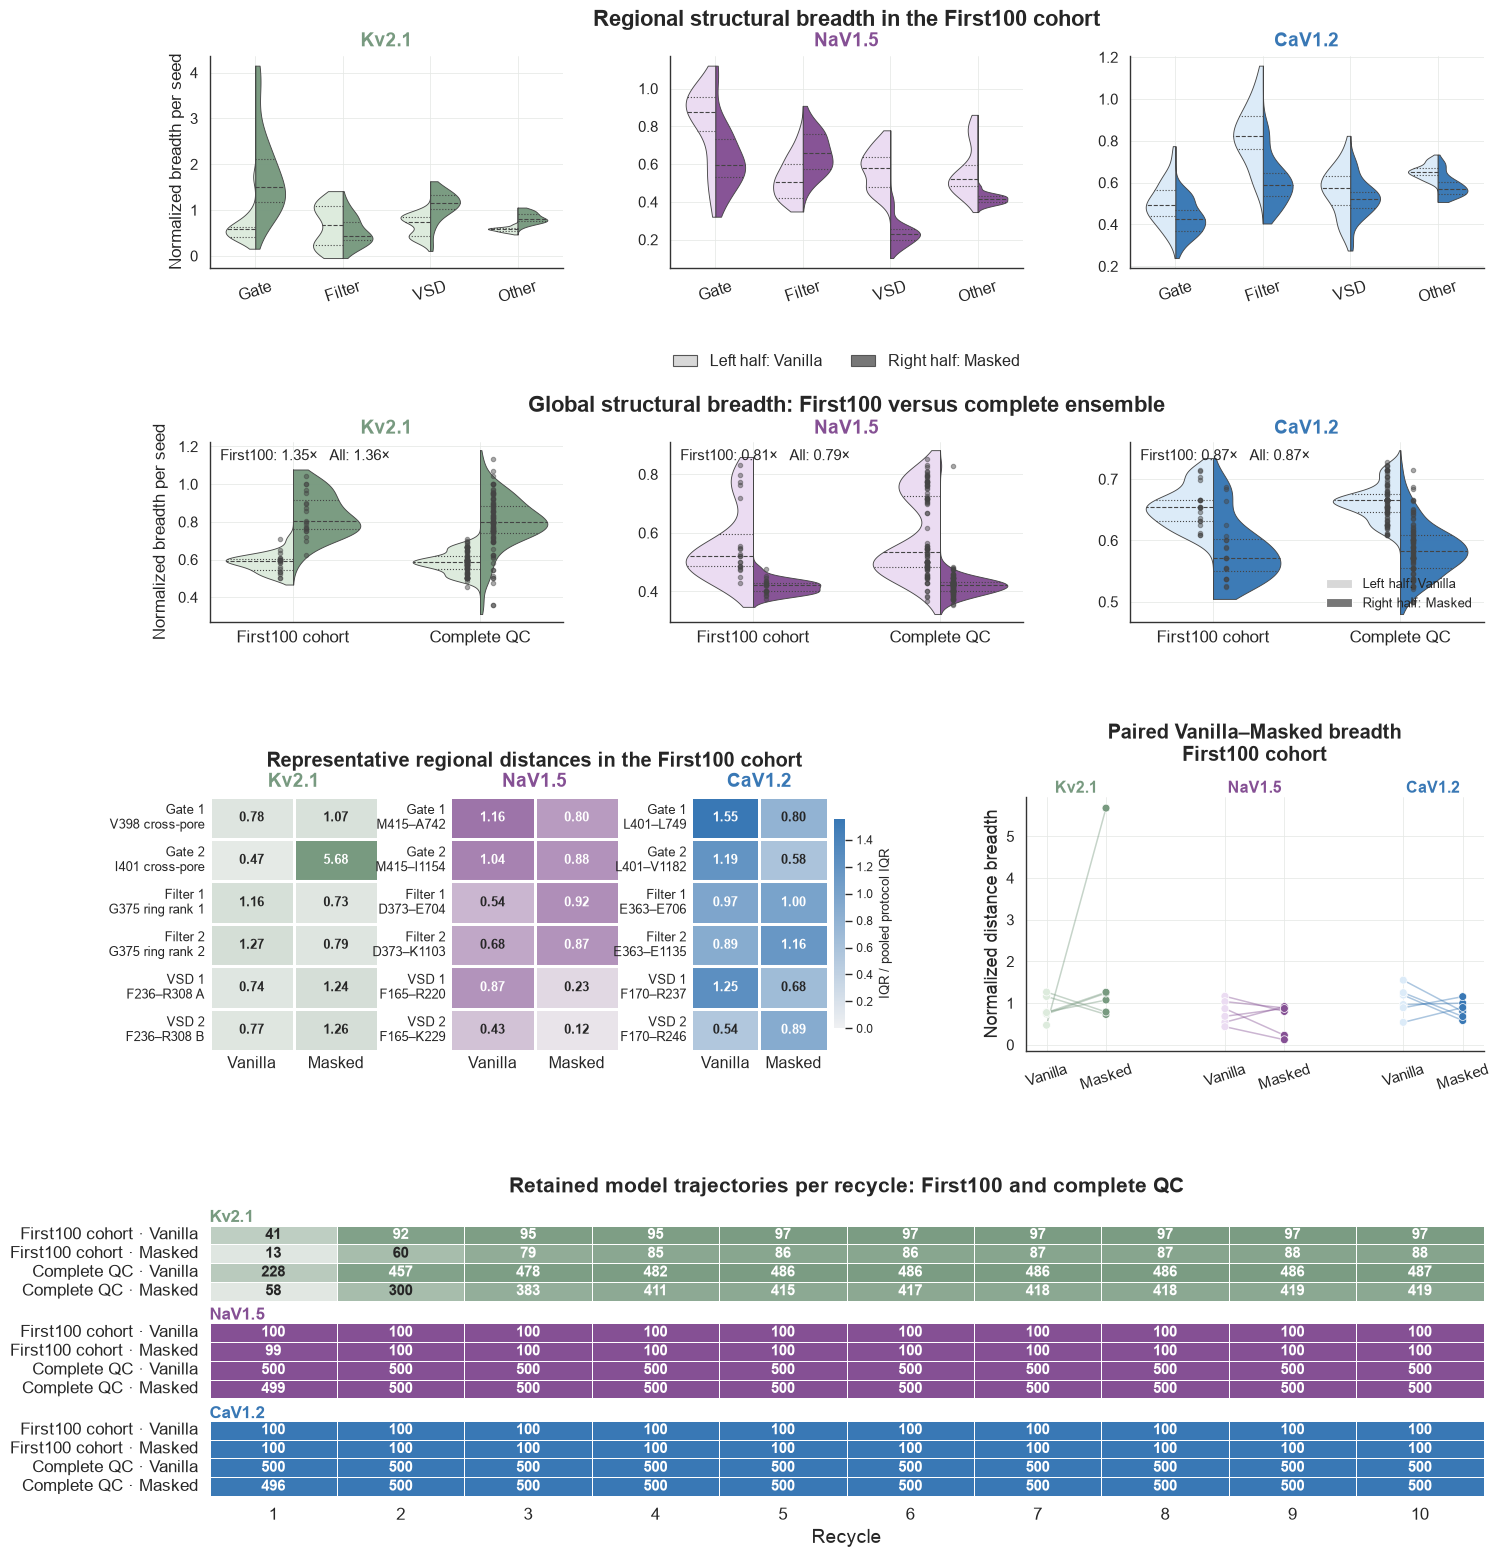

Saved: docs/figures/supplementary_figure_s8/Figure_S8_WT_First100_split_sampling_and_retention.png
Saved: docs/figures/supplementary_figure_s8/Figure_S8_WT_First100_split_sampling_and_retention.pdf


In [4]:
def split_violin(ax, x, vanilla, masked, colors, width=.38):
    all_values = pd.concat([vanilla, masked], ignore_index=True)
    pad = max(float(all_values.max() - all_values.min()) * .06, .02)
    y = np.linspace(float(all_values.min() - pad), float(all_values.max() + pad), 220)
    for values, side, color in [(vanilla, -1, colors['Vanilla']), (masked, 1, colors['Masked'])]:
        density = gaussian_kde(values.to_numpy(float))(y)
        density = density / density.max() * width
        edge = x + side * density
        ax.fill_betweenx(y, x, edge, facecolor=color, edgecolor='#444444', linewidth=.65, alpha=.98)
        for q, style in zip((.25, .5, .75), (':', '--', ':')):
            value = float(values.quantile(q))
            local_width = float(np.interp(value, y, density))
            ax.plot([x, x + side * local_width], [value, value], color='#444444', lw=.8, ls=style)

fig = plt.figure(figsize=(14, 16.0), facecolor='white')
outer = fig.add_gridspec(4, 1, height_ratios=[1.08, .92, 1.30, 1.38], hspace=.76)
fig.subplots_adjust(left=.075, right=.985, top=.965, bottom=.065)
gs_a = outer[0].subgridspec(1, 3, wspace=.30)
axes_a = []

region_order = ['Intracellular gate', 'Selectivity filter', 'Voltage-sensor domain', 'Other']
region_ticks = ['Gate', 'Filter', 'VSD', 'Other']
for col, channel in enumerate(CHANNELS):
    ax = fig.add_subplot(gs_a[0, col]); axes_a.append(ax)
    part = regional_breadth[(regional_breadth.channel == channel) & (regional_breadth.cohort == 'First100')]
    for x_pos, region_name in enumerate(region_order):
        cell = part[part.region == region_name]
        vanilla = cell.loc[cell.protocol == 'vanilla', 'normalized_seed_breadth'].reset_index(drop=True)
        masked = cell.loc[cell.protocol == 'masked', 'normalized_seed_breadth'].reset_index(drop=True)
        split_violin(ax, x_pos, vanilla, masked, COLORS[channel], width=.34)
    ax.set_xticks(range(4)); ax.set_xticklabels(region_ticks, fontsize=11.5, rotation=18)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel(''); ax.set_ylabel('Normalized breadth per seed' if col == 0 else '', fontsize=12)
    ax.set_title(DISPLAY[channel], color=COLORS[channel]['Masked'], fontsize=14, pad=7)
    sns.despine(ax=ax)

a_box = outer[0].get_position(fig)
fig.text((a_box.x0 + a_box.x1) / 2, a_box.y1 + .016,
         'Regional structural breadth in the First100 cohort',
         ha='center', va='bottom', fontsize=15.5, fontweight='semibold')
fig.legend(handles=[Patch(facecolor='#D8D8D8', edgecolor='#555555', label='Left half: Vanilla'),
                    Patch(facecolor='#777777', edgecolor='#555555', label='Right half: Masked')],
           loc='upper center', bbox_to_anchor=((a_box.x0 + a_box.x1) / 2, a_box.y0 - .045),
           ncol=2, frameon=False, fontsize=11.5, handlelength=1.5, columnspacing=1.8)

# B — global structural breadth per independent seed across every eligible distance.
gs_seed = outer[1].subgridspec(1, 3, wspace=.30)
seed_axes = []
for col, channel in enumerate(CHANNELS):
    ax_s = fig.add_subplot(gs_seed[0, col]); seed_axes.append(ax_s)
    part = seed_breadth[seed_breadth.channel == channel].copy()
    ratios = []
    for x_pos, cohort in enumerate(['First100', 'All']):
        cohort_part = part[part.cohort == cohort]
        vanilla = cohort_part.loc[cohort_part.protocol == 'vanilla', 'normalized_seed_breadth'].reset_index(drop=True)
        masked = cohort_part.loc[cohort_part.protocol == 'masked', 'normalized_seed_breadth'].reset_index(drop=True)
        split_violin(ax_s, x_pos, vanilla, masked, COLORS[channel], width=.36)
        ax_s.scatter(np.repeat(x_pos-.07, len(vanilla)), vanilla, s=10, color='#444444', alpha=.45, zorder=4)
        ax_s.scatter(np.repeat(x_pos+.07, len(masked)), masked, s=10, color='#444444', alpha=.45, zorder=4)
        ratios.append(masked.median() / vanilla.median())
    ax_s.text(.03, .96, f'First100: {ratios[0]:.2f}×   All: {ratios[1]:.2f}×',
              transform=ax_s.transAxes, ha='left', va='top', fontsize=10.5)
    ax_s.set_title(DISPLAY[channel], color=COLORS[channel]['Masked'], fontsize=14)
    ax_s.set_xlabel(''); ax_s.set_ylabel('Normalized breadth per seed' if col == 0 else '', fontsize=12, labelpad=7)
    ax_s.set_xticks([0, 1]); ax_s.set_xticklabels(['First100 cohort', 'Complete QC'], fontsize=12)
    ax_s.tick_params(axis='x', pad=1); ax_s.tick_params(axis='y', labelsize=11)
    sns.despine(ax=ax_s)
seed_axes[2].legend(handles=[Patch(facecolor='#D8D8D8', label='Left half: Vanilla'),
                             Patch(facecolor='#777777', label='Right half: Masked')],
                    frameon=False, fontsize=9.5, loc='lower right')

seed_box = outer[1].get_position(fig)
fig.text((seed_box.x0 + seed_box.x1) / 2, seed_box.y1 + .016,
         'Global structural breadth: First100 versus complete ensemble',
         ha='center', va='bottom', fontsize=15.5, fontweight='semibold')

selected_first = breadth[breadth.cohort == 'First100'].copy()
gs_b = outer[2].subgridspec(1, 2, width_ratios=[1.42, 1], wspace=.30)
gs_bh = gs_b[0, 0].subgridspec(1, 3, wspace=.43)
heat_b_axes = []
for col, channel in enumerate(CHANNELS):
    ax_h = fig.add_subplot(gs_bh[0, col]); heat_b_axes.append(ax_h)
    part = selected_first[selected_first.channel == channel].copy()
    region_short = {'Intracellular gate': 'Gate', 'Selectivity filter': 'Filter',
                    'Voltage-sensor domain': 'VSD'}
    part['region_short'] = part['region'].map(region_short)
    part['within_region'] = part.groupby('region', sort=False).cumcount() + 1
    part['label'] = (part['region_short'] + ' ' + part['within_region'].astype(str)
                     + '\n' + part['coordinate'])
    matrix = part.set_index('label')[['vanilla_normalized_IQR', 'masked_normalized_IQR']]
    matrix.columns = ['Vanilla', 'Masked']
    sns.heatmap(matrix, cmap=sns.light_palette(COLORS[channel]['Masked'], as_cmap=True),
                vmin=0, vmax=max(1.5, float(np.nanmax(matrix.to_numpy()))),
                annot=True, fmt='.2f', annot_kws={'fontsize': 9.5, 'fontweight': 'semibold'},
                linewidths=.8, linecolor='white', cbar=col == 2,
                cbar_kws={'label': 'IQR / pooled protocol IQR', 'shrink': .82, 'pad': .04}, ax=ax_h)
    ax_h.set_title(DISPLAY[channel], color=COLORS[channel]['Masked'], fontsize=13.5, pad=7)
    ax_h.set_xlabel(''); ax_h.set_ylabel('')
    ax_h.set_xticklabels(ax_h.get_xticklabels(), rotation=0, fontsize=11.5)
    ax_h.set_yticklabels(ax_h.get_yticklabels(), rotation=0, fontsize=9.5)
    ax_h.tick_params(length=0)
    ax_h.hlines([2, 4], *ax_h.get_xlim(), colors='white', linewidth=2.2)
heatmap_box = gs_b[0, 0].get_position(fig)
fig.text((heatmap_box.x0 + heatmap_box.x1) / 2, heatmap_box.y1 + .016,
         'Representative regional distances in the First100 cohort',
         ha='center', va='bottom', fontsize=14.5, fontweight='semibold')

ax_b = fig.add_subplot(gs_b[0, 1])
for channel_index, channel in enumerate(CHANNELS):
    part = selected_first[selected_first.channel == channel]
    x_v, x_m = channel_index * 3, channel_index * 3 + 1
    for _, item in part.iterrows():
        ax_b.plot([x_v, x_m], [item.vanilla_normalized_IQR, item.masked_normalized_IQR],
                  color=COLORS[channel]['Masked'], alpha=.42, lw=1.1)
        ax_b.scatter([x_v, x_m], [item.vanilla_normalized_IQR, item.masked_normalized_IQR],
                     color=[COLORS[channel]['Vanilla'], COLORS[channel]['Masked']],
                     edgecolor='white', linewidth=.5, s=32, zorder=3)
ax_b.set_xticks([0,1,3,4,6,7])
ax_b.set_xticklabels(['Vanilla','Masked'] * 3, fontsize=10.5, rotation=18)
for x, channel in zip([.5, 3.5, 6.5], CHANNELS):
    ax_b.text(x, 1.015, DISPLAY[channel], transform=ax_b.get_xaxis_transform(),
              ha='center', color=COLORS[channel]['Masked'], fontsize=11.5, fontweight='semibold')
ax_b.set_xlabel(''); ax_b.set_ylabel('Normalized distance breadth', fontsize=13); ax_b.tick_params(axis='y', labelsize=11)
ax_b.set_title('Paired Vanilla–Masked breadth\nFirst100 cohort',
               fontsize=14.5, fontweight='semibold', y=1.14, pad=0)
sns.despine(ax=ax_b)

# Compact count heatmaps make the actual number of retained trajectories explicit.
gs_h = outer[3].subgridspec(3, 1, hspace=.30)
heat_axes = []
for row, channel in enumerate(CHANNELS):
    ax = fig.add_subplot(gs_h[row, 0]); heat_axes.append(ax)
    part = retention[retention.channel == channel].copy()
    row_order = [('First100', 'vanilla'), ('First100', 'masked'),
                 ('All', 'vanilla'), ('All', 'masked')]
    matrix = part.pivot(index=['cohort', 'protocol'], columns='recycle', values='retained').reindex(row_order)
    fractions = part.pivot(index=['cohort', 'protocol'], columns='recycle', values='retained_fraction').reindex(row_order)
    labels = matrix.map(lambda value: f'{int(value)}')
    cmap = sns.light_palette(COLORS[channel]['Masked'], as_cmap=True)
    sns.heatmap(fractions, annot=labels, fmt='', cmap=cmap, vmin=0, vmax=1,
                cbar=False, linewidths=.7, linecolor='white',
                annot_kws={'fontsize': 10.5, 'fontweight': 'semibold'}, ax=ax)
    ax.set_title(DISPLAY[channel], loc='left', color=COLORS[channel]['Masked'], fontsize=12.5, pad=2)
    ax.set_ylabel(''); ax.set_yticks(np.arange(len(matrix.index)) + .5)
    cohort_labels = {'First100': 'First100 cohort', 'All': 'Complete QC'}
    ax.set_yticklabels([f'{cohort_labels[cohort]} · {protocol.capitalize()}' for cohort, protocol in matrix.index],
                       rotation=0, fontsize=12)
    ax.set_xlabel('Recycle' if row == 2 else '', fontsize=14)
    ax.tick_params(axis='x', rotation=0, labelsize=12 if row == 2 else 0)
    if row < 2: ax.set_xticklabels([])
d_box = outer[3].get_position(fig)
fig.text((d_box.x0 + d_box.x1) / 2, d_box.y1 + .018, 'Retained model trajectories per recycle: First100 and complete QC',
         ha='center', va='bottom', fontsize=15, fontweight='semibold')

png = OUT / 'Figure_S8_WT_First100_split_sampling_and_retention.png'
pdf = OUT / 'Figure_S8_WT_First100_split_sampling_and_retention.pdf'
fig.savefig(png, dpi=400, bbox_inches='tight', facecolor='white')
fig.savefig(pdf, bbox_inches='tight', facecolor='white')
display(fig); plt.close(fig)
print('Saved:', png.relative_to(repo_root)); print('Saved:', pdf.relative_to(repo_root))